In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [44]:
total_steps = 400000
# path_HYPER = '/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-1/HYPER/bg_2000_net1/beta_0.75/eh_step_0.0005'
# path_HYPER_compare = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-1/HYPER/bg_2000_net1/beta_0.75/eh_step_0.0005/compare"
# path_oracle = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-1/SAC/400K_new"
# path_HYPER_seq2 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/HYPER/bg_2500_net1/beta_0.3/eh_step_0.0005"
# path_oracle_seq2 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/SAC/sac_step_size_0.0007/reward_step_0.0003"
# path_HYPER_seq4 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.3/eh_step_0.0005"
# path_HYPER_seq4_small_embhnet_lr = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.3/eh_step_0.00007"
# path_oracle_seq4 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/SAC/actor_step_size_0.0007/critic_stepsize_0.0007/init_temperature_0.1/reward_step_0.0003/randomized_goals"
# path_oracle_seq4_small_lr = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/SAC/actor_step_size_0.00005/critic_stepsize_0.0001/init_temperature_0.1/reward_step_0.0003/fixed_goals"
path_HYPER_seq2_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/HYPER/bg_2500_net1/beta_0.3/eh_step_0.00007/fixed_goals-actual"
path_oracle_seq2_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/SAC/actor_step_size_0.0007/critic_stepsize_0.0007/init_temperature_0.1/reward_step_0.0003/fixed_goals-actual"
path_HYPER_seq2_fixed_goals_actual_beta07 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual"
path_HYPER_seq2_fixed_goals_actual_ver2 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2-ver2/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual"
path_HYPER_seq4_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.3/eh_step_0.00007/fixed_goals-actual"

path_oracle_seq4_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/SAC/actor_step_size_0.0007/critic_stepsize_0.0007/init_temperature_0.1/reward_step_0.0003/fixed_goals-actual"
path_HYPER_seq4_fixed_goals_actual_small_emb_lr = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.3/eh_step_0.00001/fixed_goals-actual"
path_HYPER_seq4_fixed_goals_actual_beta07 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-4/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual"

path_DGR_seq2_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/DGR/prev_generator/gen_update_freq_5/lambda_vae_1.0/sac_stepsize_0.0007/continual_train"
path_DGR_seq2_fixed_goals_actual_beta05 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/DGR/prev_generator/gen_update_freq_5/lambda_vae_5.0/sac_stepsize_0.0007/continual_train"
path_SI_seq2_fixed_goals_actual = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/r_step_0.0005/beta_0.1/continual_train"
path_SI_seq2_fixed_goals_actual_beta1 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/r_step_0.0005/beta_1.0/continual_train"
path_SI_seq2_fixed_goals_actual_beta10 = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/r_step_0.0005/beta_10.0/continual_train"
path_scratch = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/LFS_HNET/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual/continual_train"
path_PEBBLE = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/FT_normal/bg_2500_net1/beta_0.0/eh_step_0.00007/fixed_goals-actual"
algs = ['/HYPER', '/SI', '/DGR', '/Oracle']
num_runs = 10

In [45]:
"""
This function plots a single plot. It has some title.
Each plot can have multiple curves (and corresponding labels and colors).
Each curve consists of the sample mean of several runs and confidence interval.
"""
def plot_single(steps, stuff, legend, colors, title, figsize, xylabels, plot_mu_ci, lims, t_value, vert_lines=None, hor_lines=None, legend_loc=None, x_ticks=None, x_labels=None, summarize_plot=True):
    # 1. steps is an np array. If you want to plot x-axis from [a, b], steps == np.array([a, a+1, a+2, ..., b-1, b])
    # 2. stuff contains the data for the y-axis. It is an np array.
    # stuff should have shape of type: (ncurves, nruns, num of elements in each run i.e. the y values)
    # ncurves means the number of curves you want in a particular plot
    # nruns means the number of runs you want EACH CURVE to be averaged over
    # num of elements are the y-values for each run inside each curve
    # 3. legends is a list with "ncurves" elements, with one element for each curve. Each element is the legend label (a string) for each curve. 
    # 4. colors is a list with "ncurves" elements, with one element for each curve. Each element is the hash value (a string) for the color for each curve. 
    # 5. title is a string with the title for the plot
    # 6. figsize gives the size of the plot in the form of a tuple (A,B), where A and B and length and breadth
    # 7. xylabels is a list with 2 strings containing the label for x and y axis respecitvely
    fig = plt.figure(figsize=figsize)
    nruns = stuff.shape[1]
    for i in range(stuff.shape[0]): # for each curve
        if plot_mu_ci:
            sample_mean = np.mean(stuff[i], axis=0) # compute the sample mean for nruns for curve[i]
            sample_std = np.std(stuff[i], axis=0, ddof=1) # compute the sample std for nruns for curve[i]
            t_statistic_std_error = t_value * sample_std/np.sqrt(nruns) # compute the 1.98 * std_error; std_error = sample_std/sqrt(nruns)
            upper, lower = sample_mean + t_statistic_std_error, sample_mean - t_statistic_std_error
            plt.plot(steps, sample_mean, color=colors[i], label=legend[i])
            plt.fill_between(steps, lower, upper, color=colors[i], alpha=0.1)
        else:
            plt.plot(steps, stuff[i].squeeze(), color=colors[i], label=legend[i])
    plt.title(title, size=15)
    plt.xlabel(xylabels[0])
    plt.ylabel(xylabels[1])
    plt.xticks(ticks=x_ticks, labels=x_labels, fontsize=12)
    plt.legend(loc='lower right' if legend_loc is None else legend_loc, prop={'size': 12})
    if vert_lines is not None:
        for vl in vert_lines:
            plt.axvline(x=vl, linestyle='--', color='black')
    if hor_lines is not None:
        for hl in hor_lines:
            plt.axhline(y=hl, linestyle='--', color='black')
    if lims is not None:
        plt.gca().set_ylim(top=lims[1], bottom=lims[0])

    if summarize_plot:
        summary_runs = (np.abs(stuff[0] - stuff[1]).sum(axis=1)) / len(task_sequence)
        mean = np.mean(summary_runs)
        ci = t_value * (np.std(summary_runs, ddof=1)/np.sqrt(nruns))
        print(f'Mean difference between task and final (averaged across {nruns} runs) = {mean} \u00B1 {ci} | ({mean - ci}, {mean + ci})')
        fig.text(.5, -0.03, f'Mean difference between task and final (averaged across {nruns} runs) = {mean} \u00B1 {ci} | ({mean - ci}, {mean + ci})', ha='center', fontsize=15, weight='bold')

    # remove extra vertical padding and tighten layout
    plt.gca().margins(y=0)
    plt.tight_layout()


In [46]:
"""
This function plots a single plot. It has some title.
Each plot can have multiple curves (and corresponding labels and colors).
Each curve consists of the sample mean of several runs and confidence interval.
"""
from scipy import stats
def plot_single_modified(steps, stuff, legend, colors, title, figsize, xylabels, plot_mu_ci, lims, t_value, vert_lines=None, hor_lines=None, legend_loc=None, x_ticks=None, x_labels=None, summarize_plot=True):
    # 1. steps is an np array. If you want to plot x-axis from [a, b], steps == np.array([a, a+1, a+2, ..., b-1, b])
    # 2. stuff contains the data for the y-axis. It is a list
    # stuff should have shape of type: (ncurves, nruns, num of elements in each run i.e. the y values)
    # ncurves means the number of curves you want in a particular plot
    # nruns means the number of runs you want EACH CURVE to be averaged over
    # num of elements are the y-values for each run inside each curve
    # 3. legends is a list with "ncurves" elements, with one element for each curve. Each element is the legend label (a string) for each curve. 
    # 4. colors is a list with "ncurves" elements, with one element for each curve. Each element is the hash value (a string) for the color for each curve. 
    # 5. title is a string with the title for the plot
    # 6. figsize gives the size of the plot in the form of a tuple (A,B), where A and B and length and breadth
    # 7. xylabels is a list with 2 strings containing the label for x and y axis respecitvely
    fig = plt.figure(figsize=figsize)
    
    ymin_seen = np.inf
    ymax_seen = -np.inf

    
    for i in range(len(stuff)): # for each curve
        if plot_mu_ci:
            curve = np.array(stuff[i])
            nruns = curve.shape[0]
            sample_mean = np.mean(curve, axis=0) # compute the sample mean for nruns for curve[i]
            sample_std = np.std(curve, axis=0, ddof=1) # compute the sample std for nruns for curve[i]
            t_statistic_std_error = t_value * sample_std/np.sqrt(nruns) # compute the 1.98 * std_error; std_error = sample_std/sqrt(nruns)
            # upper, lower = sample_mean + t_statistic_std_error, sample_mean - t_statistic_std_error
            lower = sample_mean - t_statistic_std_error
            upper = sample_mean + t_statistic_std_error

            ymin_seen = min(ymin_seen, lower.min())
            ymax_seen = max(ymax_seen, upper.max())

            plt.plot(steps, sample_mean, color=colors[i], label=legend[i])
            plt.fill_between(steps, lower, upper, color=colors[i], alpha=0.1)
        else:
            plt.plot(steps,curve.squeeze(), color=colors[i], label=legend[i])
    plt.title(title, size=18)
    plt.xlabel(xylabels[0], fontsize=18)
    plt.ylabel(xylabels[1], fontsize=18)
    plt.xticks(ticks=x_ticks, labels=x_labels, fontsize=18)
    plt.legend(loc='lower right' if legend_loc is None else legend_loc, prop={'size': 16})
    if vert_lines is not None:
        for vl in vert_lines:
            plt.axvline(x=vl, linestyle='--', color='black')
    if hor_lines is not None:
        for hl in hor_lines:
            plt.axhline(y=hl, linestyle='--', color='black')
    lims = [ymin_seen, ymax_seen]
    if lims is not None:
        plt.gca().set_ylim(top=lims[1], bottom=lims[0])
    # if lims is not None:
    #     plt.gca().set_ylim(lims)
    # else:
    #     plt.gca().set_ylim(bottom=max(0.0, ymin_seen), top=ymax_seen)
    
    if summarize_plot:
        
        print("\n=== Summary Metrics (Plasticity ) ===")
        plasticity_values = {}
        for i in range(len(stuff)):
            curve = np.array(stuff[i])          # shape: (nruns, T)
            nruns, T = curve.shape
            # print(legend[i],nruns,T)

            # --- Plasticity: performance on final task ---
            # compute indices of final timestep for each task block: (j+1)*task_steps - 1
            # final_indices = [(j+1)*task_steps - 1 for j in range(num_tasks)]
            final_indices = [(j+1)*T//num_tasks - 1 for j in range(num_tasks)]
            # print(f"{legend[i]} | All final indices: {final_indices}")
            # keep only indices that exist in the recorded trajectory length T
            valid_final_indices = [idx for idx in final_indices if idx < T]
            # print(f"{legend[i]} | Valid final indices: {valid_final_indices}")
            if len(valid_final_indices) == 0:
                # fallback to last available timestep
                final_vals = curve[:, -1].reshape(nruns, 1)
            else:
                final_vals = curve[:, valid_final_indices]  # shape: (nruns, n_tasks_available)
            # print(f"{legend[i]} | Final values: {final_vals}, Shape: {final_vals.shape}")
            # average final returns across tasks for each run
            plasticity_runs = final_vals.mean(axis=1)
            plasticity_mean = np.mean(plasticity_runs)
            plasticity_ci = t_value * (np.std(plasticity_runs, ddof=1) / np.sqrt(nruns))

            # print in requested LaTeX-like format: $S\!\pm\!\delta$
            print(f"{legend[i]} | ${plasticity_mean:.3f}\\!\\pm\\!{plasticity_ci:.3f}$")
            plasticity_values[legend[i]] = plasticity_runs

        hyper_scores = plasticity_values["HYPER"]
        for i in plasticity_values:
            # print(f"{i} scores: {plasticity_values[i]}")
            t_stat, p_val = stats.ttest_ind(hyper_scores, plasticity_values[i], equal_var=False)
            print(f"P-value for {i}: {p_val}")




    # if summarize_plot:
    #     summary_runs = (np.abs(stuff[0] - stuff[1]).sum(axis=1)) / len(task_sequence)
    #     mean = np.mean(summary_runs)
    #     ci = t_value * (np.std(summary_runs, ddof=1)/np.sqrt(nruns))
    #     print(f'Mean difference between task and final (averaged across {nruns} runs) = {mean} \u00B1 {ci} | ({mean - ci}, {mean + ci})')
    #     fig.text(.5, -0.03, f'Mean difference between task and final (averaged across {nruns} runs) = {mean} \u00B1 {ci} | ({mean - ci}, {mean + ci})', ha='center', fontsize=15, weight='bold')

    # remove extra vertical padding and tighten layout
    # plt.gca().margins(y=0)
    # plt.tight_layout()


In [47]:
def compute_tuple_eval(path, what_to_plot):
    stuff_all_runs_e = []
    if path == path_oracle_seq2_fixed_goals_actual:
        runs_for_eval = 6
    else:
        runs_for_eval = num_runs
    for run in range(runs_for_eval):
        eval_csv_path = path + '/Run_{}'.format(run+1) + '/eval.csv'
        # print(eval_csv_path)
        eval_csv = pd.read_csv(eval_csv_path)
        avg_true_episode_returns_e = eval_csv[what_to_plot].values
        stuff_all_runs_e.append(avg_true_episode_returns_e)
    stuff_all_runs_e = np.array(stuff_all_runs_e)
    return stuff_all_runs_e

    if path == path_oracle_seq2_fixed_goals_actual:
        for run in range(6):
            eval_csv_path = path + '/Run_{}'.format(run+1) + '/eval.csv'
            # print(train_csv_path)
            eval_csv = pd.read_csv(eval_csv_path)
            avg_true_episode_returns_t = []
            for task in range(len(task_idx)):

                avg_true_episode_returns_t.extend(eval_csv[what_to_plot])

            stuff_all_runs_e.append(avg_true_episode_returns_t)
    else:
        for run in range(num_runs):
            eval_csv_path = path + '/Run_{}'.format(run+1) + '/eval.csv'
            print(eval_csv_path)
            
            eval_csv = pd.read_csv(eval_csv_path)
            avg_true_episode_returns_e = eval_csv[what_to_plot].values
            stuff_all_runs_e.append(avg_true_episode_returns_e)
    stuff_all_runs_e = np.array(stuff_all_runs_e)
    return stuff_all_runs_e

In [48]:
def compute_tuple_train(path, what_to_plot):
    stuff_all_runs_t = []
    for run in range(num_runs):
        train_csv_path = path + '/Run_{}'.format(run+1) + '/train.csv'
        # print(train_csv_path)
        train_csv = pd.read_csv(train_csv_path)
        avg_true_episode_returns_t = []
        for task in range(len(task_idx)):

            avg_true_episode_returns_t.extend(train_csv[what_to_plot].values[task*(total_steps//500):(task+1)*(total_steps//500)])

        stuff_all_runs_t.append(avg_true_episode_returns_t)
    stuff_all_runs_t = np.array(stuff_all_runs_t)
    return stuff_all_runs_t

In [49]:
def plot_subplots_mod2(nrows, ncols, steps, stuff, legends, colors, titles, commontitle, figsize, xylabels, plot_mu_ci, lims, t_value, legend_loc=None, plot_grids=None, vert_lines=None, horz_lines=None, plot_dots=False, x_ticks=None, x_labels=None):
    figs, axs = plt.subplots(nrows, ncols, figsize=figsize)
    if axs.ndim == 1:
        if nrows == 1:
            axs = axs.reshape(1, axs.shape[0])
        else:
            axs = axs.reshape(axs.shape[0], 1)
    plt.suptitle(commontitle, weight='bold', size=15)
    nsubplots = len(stuff)
    nruns = stuff[0][0].shape[0]
    for plot in range(nsubplots):
        ncurves = len(stuff[plot])
        row, col = plot // ncols, plot % ncols
        for curve in range(ncurves):
            if plot_mu_ci:
                sample_mean = np.mean(stuff[plot][curve], axis=0) # compute the sample mean for nruns for curve[i]
                sample_std = np.std(stuff[plot][curve], axis=0, ddof=1) # compute the sample std for nruns for curve[i]
                t_statistic_std_error = t_value * sample_std/np.sqrt(nruns) # compute the 1.98 * std_error; std_error = sample_std/sqrt(nruns)
                if plot_dots[plot]:
                    axs[row, col].plot(steps[plot][curve], sample_mean, color=colors[curve], label=legends[plot][curve], marker='o')
                else:
                    axs[row, col].plot(steps[plot][curve], sample_mean, color=colors[curve], label=legends[plot][curve])
                axs[row, col].fill_between(steps[plot][curve], sample_mean-t_statistic_std_error, sample_mean+t_statistic_std_error, 
                                            color=colors[curve], alpha=0.1)
            else:
                axs[row, col].plot(steps[plot][curve], stuff[plot][curve], color=colors[curve], label=legends[plot][curve])
        axs[row, col].legend(loc='lower right' if legend_loc[plot] is None else legend_loc[plot])
        if lims[plot] is not None:
            axs[row, col].set_ylim(lims[plot])
        axs[row, col].set_title(titles[plot], size=13)
        if plot_grids[plot]:
            axs[row, col].grid()
        if vert_lines is not None:
            for vl in range(len(vert_lines[plot])):
                axs[row, col].axvline(x=vert_lines[plot][vl], linestyle='--', color='black')
        if horz_lines is not None:
            axs[row, col].axhline(y=horz_lines[plot], linestyle='--', color='black')

        # axs[row, col].set_xticks(x_ticks, fontsize=18)
        # axs[row, col].set_xticklabels(x_labels, fontsize=18)
    # set x and y labels
    for i, ax in enumerate(axs.flat):
        ax.set(xlabel=xylabels[i][0], ylabel=xylabels[i][1])
    # Hide x labels and tick labels for top plots and y ticks for right plots.
    # for ax in axs.flat:
    #     ax.label_outer()

    # remove extra vertical padding and tighten layout
    for ax in axs.flat:
        ax.margins(y=0)
    plt.tight_layout()


In [50]:
num_runs = 10
task_steps = 400000
num_tasks = 3
x_ticks = [200000*(2*i-1) for i in range(1, num_tasks + 1)]
# x_labels = ["push-wall-v2", "shelf-place-v2", "push-back-v2"]
# x_labels = ["reach-v2","drawer-open-v2", "reach-wall-v2" ]
x_labels = ["reach-v2", "drawer-open-v2", "reach-wall-v2"]
task_idx = x_labels

# /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/mw_reach-v2/HYPER/bg_2000_net1/beta_0.75/eh_step_0.0005
# eval_csv_path = path + algs[0] + '/bg_2000_net1/beta_0.75/eh_step_0.0005' + '/Run_1/eval.csv'



In [51]:
eval_csv_path = path_HYPER_seq2_fixed_goals_actual_beta07 + '/Run_1/eval.csv'
eval_csv = pd.read_csv(eval_csv_path)
task_index = eval_csv['task_index'].values
steps_eval = eval_csv['step (eval called at this step)'].values
steps_plot = task_index * task_steps + steps_eval
print(steps_plot.shape)

train_csv_path = path_HYPER_seq2_fixed_goals_actual_beta07 + '/Run_1/train.csv'
train_csv = pd.read_csv(train_csv_path)
task_index = train_csv['task_index'].values
steps_train = train_csv['episode'].values *500
# steps_train = [1000*i for i in (steps_train)]
steps_plot_train = task_index * task_steps + steps_train
print(steps_train.shape)

stuff_all_curves = []
stuff_all_curves.append(compute_tuple_eval(path=path_HYPER_seq2_fixed_goals_actual_beta07 , what_to_plot='average_true_episode_return'))
# stuff_all_curves.append(compute_tuple_eval(path, what_to_plot='average_true_episode_return'))
stuff_all_curves = np.array(stuff_all_curves)

(123,)
(2340,)


In [52]:
plot_mu_ci = True
legend = ['r_step=0.0003', 'r_step=0.0007']
colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC', '#3E2723', '#DE970B', '#964B00', '#FF00FF']
title = f'Continual algorithms (Expanded) | Task variation in target | {num_runs} runs CIs | Running 15 episodes every 10K steps \nhdim=64,r_bs=128,bg=3000,qbs=50 \nAverage True Return | LFS'
xylabels = ['Environment steps', 'Average episodic return \n (15 episodes every 10K steps)']

t_value = 1.96
figsize = (25, 7)
lims = None
vert_lines = [task_steps * i for i in range(1, num_tasks + 1)]
hor_lines = [-5000, 0]
summarize_plot=False


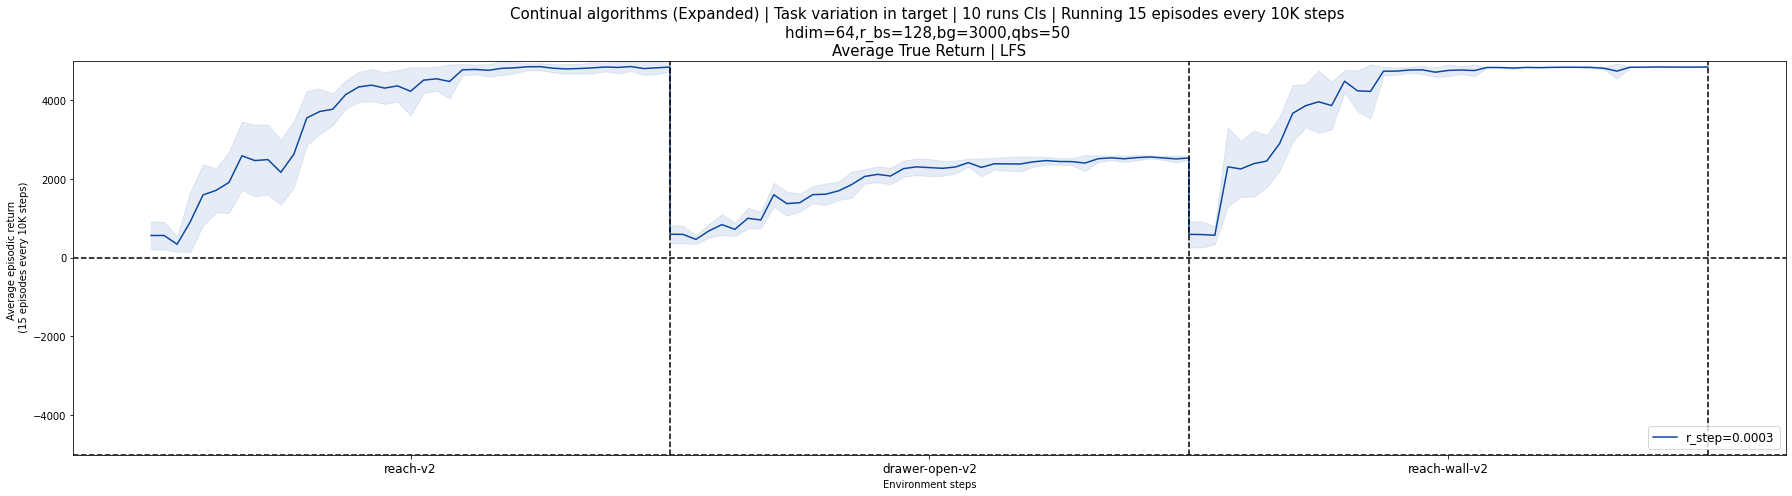

In [53]:
plot_single(steps_plot, stuff_all_curves, legend, colors, title, figsize, xylabels, plot_mu_ci, lims, t_value, vert_lines=vert_lines, hor_lines=hor_lines, x_ticks=x_ticks, x_labels=x_labels, summarize_plot=summarize_plot)


In [54]:
# print(compute_tuple_train(path_HYPER_seq4_fixed_goals_actual, 'true_episode_return').shape)
# compute_tuple_train(path_03_50, 'true_episode_return').shape

In [55]:
compute_tuple_eval(path_HYPER_seq2_fixed_goals_actual_beta07, 'average_true_episode_return').shape


(10, 123)

In [56]:
compute_tuple_eval(path_oracle_seq2_fixed_goals_actual, 'average_true_episode_return').shape

(6, 123)

In [57]:
# compute_tuple_train(path_HYPER_seq4_small_embhnet_lr, 'true_episode_return').shape

In [58]:
# compute_tuple_train(path_oracle_seq4_fixed_goals_actual, 'true_episode_return').shape

# True episode return vs step

In [59]:
# # Prepare data for all algorithms
# stuff_all_curves = [
#     # compute_tuple_train(path_HYPER_seq2, 'true_episode_return'),
#     # compute_tuple_train(path_oracle_seq2, 'true_episode_return'),
#     # compute_tuple_train(path_HYPER_seq4, 'true_episode_return'),
#     # compute_tuple_train(path_HYPER_seq4_small_embhnet_lr, 'true_episode_return'),
#     # compute_tuple_train(path_oracle_seq4, 'true_episode_return'),
    
    
    
#     # compute_tuple_train(path_HYPER_seq2_fixed_goals_actual, 'true_episode_return'),
#     # compute_tuple_train(path_HYPER_seq2_fixed_goals_actual_compare, 'true_episode_return'),
#     compute_tuple_train(path_HYPER_seq2_fixed_goals_actual_beta07, 'true_episode_return'),
#     compute_tuple_train(path_oracle_seq2_fixed_goals_actual, 'true_episode_return'),
#     compute_tuple_train(path_DGR_seq2_fixed_goals_actual, 'true_episode_return'), 
#     compute_tuple_train(path_DGR_seq2_fixed_goals_actual_beta05, 'true_episode_return'),
#     compute_tuple_train(path_scratch, 'true_episode_return'),
#     compute_tuple_train(path_SI_seq2_fixed_goals_actual_beta1, 'true_episode_return'),
#     compute_tuple_train(path_SI_seq2_fixed_goals_actual_beta10, 'true_episode_return'),
#     # compute_tuple_train(path_HYPER_seq4_fixed_goals_actual_small_emb_lr, 'true_episode_return'),
#     # compute_tuple_train(path_HYPER_seq4_fixed_goals_actual, 'true_episode_return'),
#     # compute_tuple_train(path_HYPER_seq4_fixed_goals_actual_beta07, 'true_episode_return'),
#     # compute_tuple_train(path_HYPER_seq4_fixed_goals_actual_compare, 'true_episode_return'),
#     # compute_tuple_train(path_oracle_seq4_fixed_goals_actual, 'true_episode_return'),
#     # compute_tuple_train(path_oracle_seq4_small_lr, 'true_episode_return')

# ]
# stuff_all_curves = np.array(stuff_all_curves)

# print(stuff_all_curves.shape)

# # legend = ['0.001', '0.0003-0.75', '0.0003-0.50', '0.0003-0.25', 'oracle']
# legend = [
#     'HYPER-Seq-2',
#     # 'HYPER-Seq-2-compare',
#     'oracle-Seq-2',
#     "DGR-Seq-2-lambda1.0",
#     "DGR-Seq-2-lambda5.0",
#     "scratch-Seq-2",
#     "SI-Seq-2-beta1.0",
#     "SI-Seq-2-beta10.0",
#     # 'HYPER-Seq-4-small-emb-lr',
#     # 'HYPER-Seq-4',
    
#     # 'oracle-Seq-4',

# ]
# colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC', '#3E2723', '#DE970B', '#964B00', '#FF00FF', '#8B0000', '#4682B4', '#FFD700']
# title = f'Continual RL Algorithms Comparison | {num_runs} runs CIs'
# xylabels = ['Environment steps', 'True episodic return']

# plot_single(
#     steps_plot_train,
#     stuff_all_curves,
#     legend,
#     colors,
#     title,
#     figsize,
#     xylabels,
#     plot_mu_ci,
#     lims,
#     t_value,
#     vert_lines=vert_lines,
#     hor_lines=hor_lines,
#     x_ticks=x_ticks,
#     x_labels=x_labels,
#     summarize_plot=False
# )

In [60]:

# import numpy as np

def swap_tasks_in_curves(curves, num_tasks=3, swap_pair=(0,1)):
    """
    Swap two task blocks in time-series evaluation curves.
    curves: array-like with shape (nruns, ...) where axes after axis 0 are time (may be multi-dim).
    Returns array with same shape where the blocks for tasks swap_pair[0] and swap_pair[1] are exchanged.
    """
    a = np.array(curves)
    if a.size == 0:
        return a

    # treat 1D (single run) as (1, T)
    single_run = False
    if a.ndim == 1:
        a = a.reshape(1, -1)
        single_run = True

    nruns = a.shape[0]
    # flatten per-run non-run axes to a single time dimension
    flat = a.reshape(nruns, -1)
    T = flat.shape[1]
    samples_per_task = T // num_tasks
    if samples_per_task == 0:
        raise ValueError(f"Detected T={T} < num_tasks={num_tasks}; cannot split tasks.")

    # compute start/end indices for each task; last task takes remainder
    starts = [i * samples_per_task for i in range(num_tasks)]
    ends = [(i+1) * samples_per_task for i in range(num_tasks)]
    ends[-1] = T

    i0, i1 = swap_pair
    if not (0 <= i0 < num_tasks and 0 <= i1 < num_tasks):
        raise ValueError("swap_pair indices must be in range(num_tasks)")

    new_flat = np.empty_like(flat)
    for r in range(nruns):
        segments = [flat[r, starts[i]:ends[i]] for i in range(num_tasks)]
        # swap requested segments
        segments[i0], segments[i1] = segments[i1], segments[i0]
        new_flat[r] = np.concatenate(segments)

    # reshape back to original per-run shape
    new_arr = new_flat.reshape((nruns,) + a.shape[1:])
    if single_run:
        return new_arr.reshape(-1)  # return 1D as original
    return new_arr

# Example: load ver2 eval curves and produce swapped version (swap task0 and task1)
curves_ver2 = compute_tuple_eval(path_HYPER_seq2_fixed_goals_actual_ver2, 'average_true_episode_return')
print("ver2 original shape:", np.array(curves_ver2).shape)
curves_ver2_swapped = swap_tasks_in_curves(curves_ver2, num_tasks=num_tasks, swap_pair=(0,1))
print("ver2 swapped shape:", np.array(curves_ver2_swapped).shape)

# Use curves_ver2_swapped when plotting / comparisons
# e.g. replace the ver2 entry in stuff_all_curves before calling plot_single_modified:
# stuff_all_curves = [
#     compute_tuple_eval(path_HYPER_seq2_fixed_goals_actual_beta07, 'average_true_episode_return'),
#     compute_tuple_eval(path_oracle_seq2_fixed_goals_actual, 'average_true_episode_return'),
#     curves_ver2_swapped,
# compute_tuple_eval(path_HYPER_seq2_fixed_goals_actual_ver2, 'average_true_episode_return')

ver2 original shape: (10, 123)
ver2 swapped shape: (10, 123)


# Eval Plot


=== Summary Metrics (Plasticity ) ===
HYPER | $4064.211\!\pm\!36.579$
Oracle | $4170.241\!\pm\!127.324$
DGR-1.0 | $4035.775\!\pm\!68.987$
DGR-5.0 | $3989.321\!\pm\!149.164$
SI-0.1 | $3831.089\!\pm\!189.067$
SI-1.0 | $3779.640\!\pm\!195.704$
SI-10.0 | $2520.522\!\pm\!163.993$
Scratch | $3946.966\!\pm\!134.422$
P-value for HYPER: 1.0
P-value for Oracle: 0.1691207063482716
P-value for DGR-1.0: 0.48736660649145214
P-value for DGR-5.0: 0.361577521506124
P-value for SI-0.1: 0.03989240964881422
P-value for SI-1.0: 0.019405367517791015
P-value for SI-10.0: 6.87442717033946e-09
P-value for Scratch: 0.12908399637909165


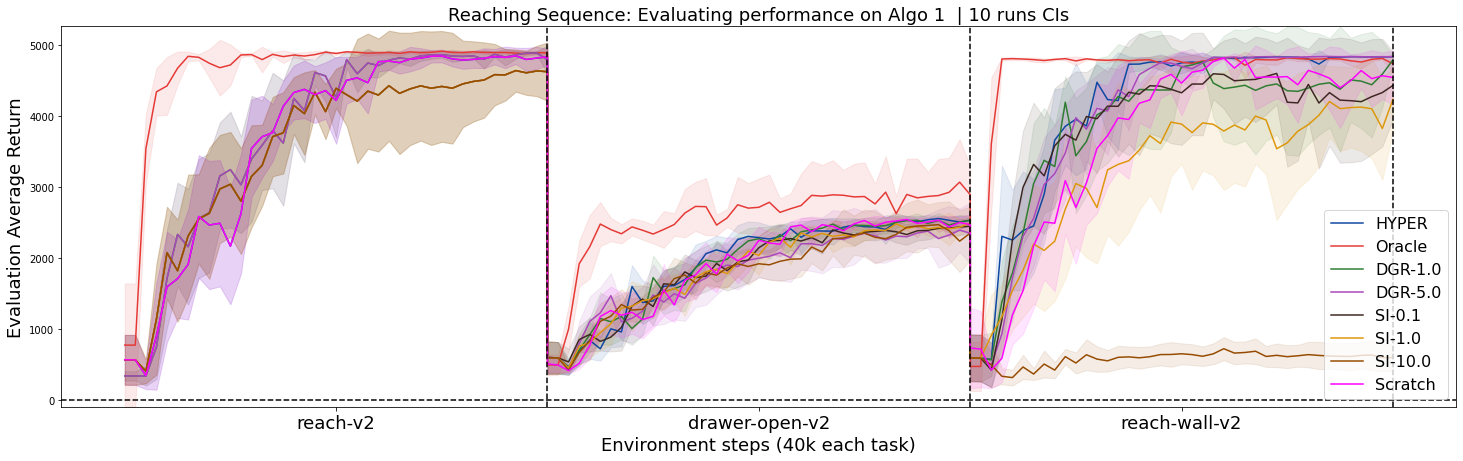

In [65]:
# Prepare data for all algorithms
stuff_all_curves = [
    # compute_tuple_eval(path_HYPER_seq2_fixed_goals_actual, 'average_true_episode_return'),
    compute_tuple_eval(path_HYPER_seq2_fixed_goals_actual_beta07, 'average_true_episode_return'),
    compute_tuple_eval(path_oracle_seq2_fixed_goals_actual, 'average_true_episode_return'),
    # curves_ver2_swapped,
    # compute_tuple_eval(path_HYPER_seq4_fixed_goals_actual_small_emb_lr, 'average_true_episode_return'),
    # compute_tuple_eval(path_HYPER_seq4_fixed_goals_actual, 'average_true_episode_return'),
    # compute_tuple_eval(path_HYPER_seq4_fixed_goals_actual_beta07, 'average_true_episode_return'),
    compute_tuple_eval(path_DGR_seq2_fixed_goals_actual, 'average_true_episode_return'), 
    compute_tuple_eval(path_DGR_seq2_fixed_goals_actual_beta05, 'average_true_episode_return'),
    compute_tuple_eval(path_SI_seq2_fixed_goals_actual, 'average_true_episode_return'), 
    compute_tuple_eval(path_SI_seq2_fixed_goals_actual_beta1, 'average_true_episode_return'),
    compute_tuple_eval(path_SI_seq2_fixed_goals_actual_beta10, 'average_true_episode_return'),
    compute_tuple_eval(path_scratch, 'average_true_episode_return'),
    # compute_tuple_eval(path_PEBBLE, 'average_true_episode_return'),
    # compute_tuple_eval(path_HYPER_seq4_small_embhnet_lr, 'average_true_episode_return'),
    # compute_tuple_eval(path_oracle_seq4_fixed_goals_actual, 'average_true_episode_return')
    # compute_tuple_train(path_oracle_seq4_small_lr, 'true_episode_return')

]
# stuff_all_curves = np.array(stuff_all_curves)

# print(stuff_all_curves.shape)

# legend = ['0.001', '0.0003-0.75', '0.0003-0.50', '0.0003-0.25', 'oracle']
legend = [
    # 'HYPER-Seq-2',
    'HYPER',
    'Oracle',
    # 'HYPER-Seq-2-ver2',
    "DGR-1.0",
    "DGR-5.0",
    "SI-0.1",
    "SI-1.0",
    "SI-10.0",
    "Scratch",
    # "PEBBLE"
    # 'HYPER-Seq-4-small-emb-lr',

    # 'HYPER-Seq-4',
    # 'HYPER-Seq-4-beta07',
    # 'HYPER-smaller-emb-lr-Seq-4',
    # 'oracle-Seq-4',
    # "oracle-small-lr"
]
colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC', '#3E2723', '#DE970B', '#964B00', '#FF00FF', '#8B0000', '#4682B4', '#FFD700']
title = f'Reaching Sequence: Evaluating performance on Algo 1  | {num_runs} runs CIs'
xylabels = ['Environment steps (40k each task)', 'Evaluation Average Return']

plot_single_modified(
    steps_plot,
    stuff_all_curves,
    legend,
    colors,
    title,
    figsize,
    xylabels,
    plot_mu_ci,
    lims,
    t_value,
    vert_lines=vert_lines,
    hor_lines=hor_lines,
    x_ticks=x_ticks,
    x_labels=x_labels,
    summarize_plot=True
)

# Eval Plots: DGR

In [62]:
# Compute Forward Transfer (FT) for HYPER, SI, DGR vs Scratch baseline
# Now with normalization: normalize all training curves to [0,1] using the global min/max across all loaded curves
# Then compute AUC per task (trapezoidal integral normalized by segment length) and FT_i.


def compute_auc_per_task(curves, samples_per_task, num_tasks):
    # curves: (nruns, T_total) -- assumed normalized in [0,1]
    nruns, T = curves.shape
    print(f"compute_auc_per_task: curves.shape={curves.shape}, samples_per_task={samples_per_task}, num_tasks={num_tasks}")
    aucs_per_run = np.full((nruns, num_tasks), np.nan)
    for r in range(nruns):
        for t in range(num_tasks):
            start = t * samples_per_task
            end = (t + 1) * samples_per_task
            end = min(end, T)
            seg = curves[r, start:end]
            if len(seg) == 0:
                auc = np.nan
            else:
                # trapezoidal area normalized by segment length -> gives mean value over segment
                auc = np.trapz(seg) / max(len(seg), 1)
            aucs_per_run[r, t] = auc
    mean_aucs = np.nanmean(aucs_per_run, axis=0)
    std_aucs = np.nanstd(aucs_per_run, axis=0, ddof=1)
    n_nans = np.sum(np.isnan(aucs_per_run), axis=0)
    print("AUC per-task summary (on normalized [0,1] curves):")
    for t in range(num_tasks):
        print(f"  Task {t+1}: mean={mean_aucs[t]:.4f}, std={std_aucs[t]:.4f}, n_nans={n_nans[t]}")
    return aucs_per_run, mean_aucs


def load_curves_only(path, what='true_episode_return'):
    if path is None or path == '':
        print(f"load_curves_only: empty path")
        return None
    try:
        curves = compute_tuple_train(path, what)
        # print(f"Loaded training curves from {path} using compute_tuple_train")
    except Exception:
        try:
            curves = compute_tuple_eval(path, what)
            print(f"Loaded eval curves from {path} using compute_tuple_eval")
        except Exception as e:
            print(f'Failed to load curves for {path}: {e}')
            return None
    return curves

# Paths to evaluate - include variants for SI and DGR
alg_paths = {
    'HYPER':  globals().get('path_HYPER_seq2_fixed_goals_actual_beta07', None) ,
    'HYPER-ver2': globals().get('path_HYPER_seq2_fixed_goals_actual_ver2', None),
    'SI-0.1': globals().get('path_SI_seq2_fixed_goals_actual', None),
    'SI-1.0': globals().get('path_SI_seq2_fixed_goals_actual_beta1', None),
    'SI-10.0': globals().get('path_SI_seq2_fixed_goals_actual_beta10', None),
    'DGR-1.0': globals().get('path_DGR_seq2_fixed_goals_actual', None),
    'DGR-5.0': globals().get('path_DGR_seq2_fixed_goals_actual_beta05', None),
    'Scratch': globals().get('path_scratch', None)
}

print('Using paths:')
for k,v in alg_paths.items():
    print(f'  {k}: {v}')

# First load all raw curves
raw_curves = {}
for name, p in alg_paths.items():
    raw = load_curves_only(p, what='true_episode_return')
    if name=="HYPER-ver2":
        raw = curves_ver2_swapped
    raw_curves[name] = raw
    # if raw is not None:
    #     print(f"{name} raw shape: {raw.shape}")

# compute global min/max across all available curves for normalization
all_values = []
for name, arr in raw_curves.items():
    if arr is None:
        continue
    try:
        all_values.append(np.nanmin(arr))
        all_values.append(np.nanmax(arr))
    except Exception:
        pass

if len(all_values) == 0:
    print('No curves loaded. Cannot compute FT.')
else:
    global_min = min(all_values)
    global_max = max(all_values)
    print(f"Global min across curves = {global_min:.4f}, Global max across curves = {global_max:.4f}")
    normalize = True
    if np.isclose(global_max, global_min):
        print('Warning: global_max == global_min; skipping normalization (all values constant).')
        normalize = False

    # normalize curves and compute AUCs
    results = {}
    for name, raw in raw_curves.items():
        if raw is None:
            results[name] = {'curves': None, 'aucs_per_run': None, 'aucs_mean': None}
            continue
        if normalize:
            curves = (raw - global_min) / (global_max - global_min)
        else:
            curves = raw.astype(float)
        # infer samples_per_task
        nruns, T = curves.shape
        samples_per_task = max(1, T // num_tasks)
        aucs_per_run, mean_aucs = compute_auc_per_task(curves, samples_per_task, num_tasks)
        results[name] = {'curves': curves, 'aucs_per_run': aucs_per_run, 'aucs_mean': mean_aucs}
        print(f"Computed AUCs for {name}: mean per task = {mean_aucs}")

    # Verify baseline
    if results.get('Scratch') is None or results['Scratch']['aucs_mean'] is None:
        print('Scratch baseline not found or failed to load; cannot compute FT')
    else:
        baseline = results['Scratch']['aucs_mean']
        print('\nBaseline (Scratch) AUC per task (on normalized scale):')
        for t, val in enumerate(baseline, start=1):
            print(f"  Task {t}: baseline AUC = {val:.4f}")

        print('\nPer-task AUC means and FT by algorithm:')
        algs_to_report = [k for k in alg_paths.keys() if k != 'Scratch']
        for name in algs_to_report:
            entry = results.get(name)
            if entry is None or entry['aucs_mean'] is None:
                print(f"{name}: data missing")
                continue
            auc_mean = entry['aucs_mean']
            aucs_per_run = entry['aucs_per_run']
            denom = (1.0 - baseline)
            denom_safe = np.where(np.isclose(denom, 0.0), np.nan, denom)
            ft = (auc_mean - baseline) / denom_safe
            per_run_ft = (aucs_per_run - baseline[np.newaxis, :]) / denom_safe[np.newaxis, :]
            per_run_mean = np.nanmean(per_run_ft, axis=0)
            per_run_std = np.nanstd(per_run_ft, axis=0, ddof=1)

            print(f"\n{name}:")
            for t_idx in range(len(auc_mean)):
                marker = ' <-- TASK 3' if (t_idx+1) == 3 else ''
                print(f"  Task {t_idx+1}: mean AUC = {auc_mean[t_idx]:.4f}, FT = {ft[t_idx]:.4f}{marker}")
                print(f"    per-run FT: mean={per_run_mean[t_idx]:.4f}, std={per_run_std[t_idx]:.4f}")

        # summary
        print('\nSummary (mean FT across tasks):')
        for name in algs_to_report:
            entry = results.get(name)
            if entry is None or entry['aucs_mean'] is None:
                continue
            auc_mean = entry['aucs_mean']
            denom_safe = np.where(np.isclose(1.0 - baseline, 0.0), np.nan, (1.0 - baseline))
            ft = (auc_mean - baseline) / denom_safe
            print(f"{name}: mean FT = {np.nanmean(ft):.4f}")

    print('\nNote: curves were normalized using global min/max across available training curves before AUC computation.')


Using paths:
  HYPER: /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual
  HYPER-ver2: /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/new/Metaworld/MW-Seq-2-ver2/HYPER/bg_2500_net1/beta_0.7/eh_step_0.00007/fixed_goals-actual
  SI-0.1: /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/r_step_0.0005/beta_0.1/continual_train
  SI-1.0: /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/r_step_0.0005/beta_1.0/continual_train
  SI-10.0: /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/r_step_0.0005/beta_10.0/continual_train
  DGR-1.0: /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/DGR/prev_generator/gen_update_freq_5/lambda_vae_1.0/sac_stepsize_0.0007/continual_train
  DGR-5.0: /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/DGR/prev_generator/gen_update_freq_5/lambda_vae_5.0/sac_stepsize_0.0007/con

In [63]:
# Prepare a list of (path, array) tuples for sorting
curve_data = [
    (path_03_75, stuff_all_curves_03_075_01),
    (path_03_75_01, stuff_all_curves_03_075_01),
    (path_03_75_1, stuff_all_curves_03_075_1),
    (path_03_25, stuff_all_curves_03_25),
    (path_03_25_01, stuff_all_curves_03_25_01),
    (path_03_25_1, stuff_all_curves_03_25_1),
    (path_03_50, stuff_all_curves_03_50),
    (path_03_50_01, stuff_all_curves_03_50_01),
    (path_03_50_1, stuff_all_curves_03_50_1),
    (path_SI_01, stuff_all_curves_SI_01),
    (path_SI_1, stuff_all_curves_SI_1),
    (path_SI_10, stuff_all_curves_SI_10),
    (path_DGR_1, stuff_all_curves_DGR_1),
    (path_DGR_5, stuff_all_curves_DGR_5),
    (path_oracle, stuff_all_curves_oracle)
]

# Compute mean and variance for each
stats = []
for p, arr in curve_data:
    mean = np.mean(arr)
    var = np.var(arr, ddof=1)
    stats.append((p, mean, var))

# Sort by mean (ascending)
sorted_by_mean = sorted(stats, key=lambda x: x[1])
print("Sorted by mean:")
for p, mean, var in sorted_by_mean:
    print(f"Hyperparameters: {p}\n  Mean: {mean:.2f}  Variance: {var:.2f}")

# Sort by variance (ascending)
sorted_by_var = sorted(stats, key=lambda x: x[2])
print("\nSorted by variance:")
for p, mean, var in sorted_by_var:
    print(f"Path: {p}\n  Variance: {var:.2f}  Mean: {mean:.2f}")

# Consolidated list sorted by mean/sqrt(variance)
mean_sqrtvar_stats = []
for p, arr in curve_data:
    mean = np.mean(arr)
    var = np.var(arr, ddof=1)
    score = mean / np.sqrt(var) if var > 0 else float('inf')
    # score = mean / (var) if var > 0 else float('inf')
    mean_sqrtvar_stats.append((p, mean, var, score))

sorted_by_score = sorted(mean_sqrtvar_stats, key=lambda x: x[3], reverse=True)
print("\nSorted by mean/sqrt(variance):")
for p, mean, var, score in sorted_by_score:
    print(f"Path: {p}\n  Mean: {mean:.2f}  Variance: {var:.2f}  Mean/sqrt(Var): {score:.2f}")



NameError: name 'path_03_75' is not defined

In [ ]:
print("stuff_all_curves_03_075_01")
print(np.mean(stuff_all_curves_03_075_01), np.std(stuff_all_curves_03_075_01, ddof=1))

print("stuff_all_curves_03_075_1")
print(np.mean(stuff_all_curves_03_075_1), np.std(stuff_all_curves_03_075_1, ddof=1))

print("stuff_all_curves_03_25")
print(np.mean(stuff_all_curves_03_25), np.std(stuff_all_curves_03_25, ddof=1))

print("stuff_all_curves_03_25_01")
print(np.mean(stuff_all_curves_03_25_01), np.std(stuff_all_curves_03_25_01, ddof=1))

print("stuff_all_curves_03_25_1")
print(np.mean(stuff_all_curves_03_25_1), np.std(stuff_all_curves_03_25_1, ddof=1))

print("stuff_all_curves_03_50")
print(np.mean(stuff_all_curves_03_50), np.std(stuff_all_curves_03_50, ddof=1))

print("stuff_all_curves_03_50_01")
print(np.mean(stuff_all_curves_03_50_01), np.std(stuff_all_curves_03_50_01, ddof=1))

print("stuff_all_curves_03_50_1")
print(np.mean(stuff_all_curves_03_50_1), np.std(stuff_all_curves_03_50_1, ddof=1))

print("stuff_all_curves_DGR")
print(np.mean(stuff_all_curves_DGR), np.std(stuff_all_curves_DGR, ddof=1))

print("stuff_all_curves_oracle")
print(np.mean(stuff_all_curves_oracle), np.std(stuff_all_curves_oracle, ddof=1))

stuff_all_curves_03_075_01
-845.98079009547 412.023639187613
stuff_all_curves_03_075_1
-749.6581527471279 439.17709410334504
stuff_all_curves_03_25
-912.4121381264789 423.4322002541996
stuff_all_curves_03_25_01
-878.4504511343229 409.6100675251885
stuff_all_curves_03_25_1
-775.5050798172452 393.35137698259786
stuff_all_curves_03_50
-868.0681608849944 419.0149078319047
stuff_all_curves_03_50_01
-839.0990212950069 417.53236600573604
stuff_all_curves_03_50_1
-1075.5237267870507 619.2626417606016
stuff_all_curves_DGR
-743.2601630824614 354.6275631714698
stuff_all_curves_oracle
-142.95220704820878 295.9466374617478


In [ ]:
for i in range(stuff_all_curves_oracle.shape[0]):
    print(np.mean(stuff_all_curves_oracle[i]), np.std(stuff_all_curves_oracle[i], ddof=1))

for i in range(stuff_all_curves_03_50.shape[0]):
    print(np.mean(stuff_all_curves_03_50[i]), np.std(stuff_all_curves_03_50[i], ddof=1))
    
for i in range(stuff_all_curves_03_075.shape[0]):
    print(np.mean(stuff_all_curves_03_075[i]), np.std(stuff_all_curves_03_075[i], ddof=1))

-142.42122712337058 297.1236621874765
-143.48318697304697 295.3772277401765
-756.2944080791328 376.2964792032285
-979.841913690856 430.75736137154445
-743.2601630824614 354.6275631714698


# learned episode return vs step

In [ ]:
stuff_all_curves = [
    compute_tuple_train(path_1, 'learned_episode_return'),
    # compute_tuple_eval(path_DGR, 'average_true_episode_return'),
    compute_tuple_train(path_03, 'learned_episode_return'),
    # compute_tuple_train(path_oracle, 'learned_episode_return')
]
stuff_all_curves = np.array(stuff_all_curves)

legend = ['0.001', '0.0003']
colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC']
title = f'Continual RL Algorithms Comparison | {num_runs} runs CIs'
xylabels = ['Environment steps', 'Average episodic return\n(15 episodes every 10K steps)']

plot_single(
    steps_plot_train,
    stuff_all_curves,
    legend,
    colors,
    title,
    figsize,
    xylabels,
    plot_mu_ci,
    lims,
    t_value,
    vert_lines=vert_lines,
    hor_lines=hor_lines,
    x_ticks=x_ticks,
    x_labels=x_labels,
    summarize_plot=False
)

/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.001/reg_beta_0.75/continual_train/Run_1/train.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.001/reg_beta_0.75/continual_train/Run_2/train.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.0003/reg_beta_0.75/continual_train/Run_1/train.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.0003/reg_beta_0.75/continual_train/Run_2/train.csv


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 2) + inhomogeneous part.

/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.001/reg_beta_0.75/continual_train/Run_1/train.csv
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/emb_hnet_stepsize_0.0005/sac_step_size_0.0003/reg_beta_0.75/continual_train/Run_1/train.csv


/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/.CPRL_venv/lib/python3.10/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/.CPRL_venv/lib/python3.10/site-packages/numpy/core/_methods.py:258: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/.CPRL_venv/lib/python3.10/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/.CPRL_venv/lib/python3.10/site-packages/numpy/core/_methods.py:258: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


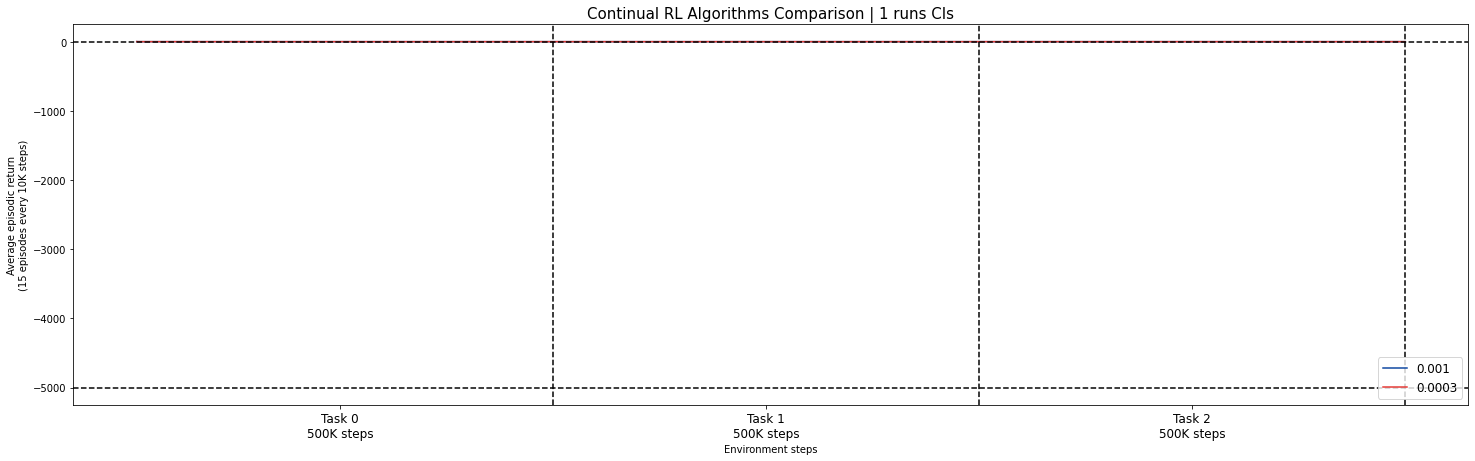

In [ ]:
stuff_all_curves = [
    compute_tuple_train(path_1, 'rew_adaptation_acc'),
    # compute_tuple_eval(path_DGR, 'average_true_episode_return'),
    compute_tuple_train(path_03, 'rew_adaptation_acc'),
    # compute_tuple_eval(path_ER, 'average_true_episode_return')
]
stuff_all_curves = np.array(stuff_all_curves)

legend = ['0.001', '0.0003']
colors = ['#0D47A1', '#E53935', '#2E7D32', '#AB47BC']
title = f'Continual RL Algorithms Comparison | {num_runs} runs CIs'
xylabels = ['Environment steps', 'Average episodic return\n(15 episodes every 10K steps)']

plot_single(
    steps_plot_train,
    stuff_all_curves,
    legend,
    colors,
    title,
    figsize,
    xylabels,
    plot_mu_ci,
    lims,
    t_value,
    vert_lines=vert_lines,
    hor_lines=hor_lines,
    x_ticks=x_ticks,
    x_labels=x_labels,
    summarize_plot=False
)

In [ ]:
# Create LaTeX-ready rows for Task 3 Forward Transfer (FT)
# Columns: HYPER, SI-0.1, SI-1.0, SI-10.0, DGR-1.0, DGR-5.0
# This prints three rows: HalfCheetah Sequence, Reaching Sequence (this notebook), Pressing Sequence.

task3_idx = 2  # zero-based index for Task 3
cols = ['HYPER','SI-0.1','SI-1.0','SI-10.0','DGR-1.0','DGR-5.0']

def fmt_entry(name):
    # return a LaTeX-ready string for the column
    if 'results' not in globals():
        return '[VAL] \\pm [STD]'
    if results.get('Scratch') is None or results['Scratch']['aucs_mean'] is None:
        return '[VAL] \\pm [STD]'
    entry = results.get(name)
    if entry is None or entry['aucs_per_run'] is None:
        return '[VAL] \\pm [STD]'
    aucs_per_run = entry['aucs_per_run']
    baseline = results['Scratch']['aucs_mean']
    denom_safe = np.where(np.isclose(1.0 - baseline, 0.0), np.nan, (1.0 - baseline))
    per_run_ft = (aucs_per_run - baseline[np.newaxis, :]) / denom_safe[np.newaxis, :]
    # select task 3
    try:
        per_run_ft_task = per_run_ft[:, task3_idx]
    except Exception:
        return '[VAL] \\pm [STD]'
    mean_ft = np.nanmean(per_run_ft_task)
    std_ft = np.nanstd(per_run_ft_task, ddof=1)
    if np.isnan(mean_ft) or np.isnan(std_ft):
        return '[VAL] \\pm [STD]'
    # format with sign for readability and two decimals
    return f'${mean_ft:+.2f} \\pm {std_ft:.2f}$'

vals_reaching = [fmt_entry(c) for c in cols]

# placeholders for sequences not computed in this notebook
placeholders = ['[VAL] \\pm [STD]'] * len(cols)

# Print LaTeX rows exactly copy-paste ready
print(r"\textbf{Ours} & \multicolumn{3}{c|}{\textbf{Synaptic Intelligence (SI)}} & \multicolumn{2}{c}{\textbf{Deep Gen. Replay (DGR)}} \\")
print(r"         & \textbf{HYPER} & $\beta=0.1$ & $\beta=1.0$ & $\beta=10.0$ & $\lambda=1.0$ & $\lambda=5.0$ \\")
print(r"        \midrule")
print(r"        \textbf{HalfCheetah Sequence} & " + " & ".join(placeholders) + r" \\")
print(r"        \textbf{Reaching Sequence}    & " + " & ".join(vals_reaching) + r" \\")
print(r"        \textbf{Pressing Sequence}    & " + " & ".join(placeholders) + r" \\")

print('\n# Copy-paste the three rows above into your LaTeX table.')

\textbf{Ours} & \multicolumn{3}{c|}{\textbf{Synaptic Intelligence (SI)}} & \multicolumn{2}{c}{\textbf{Deep Gen. Replay (DGR)}} \\
         & \textbf{HYPER} & $\beta=0.1$ & $\beta=1.0$ & $\beta=10.0$ & $\lambda=1.0$ & $\lambda=5.0$ \\
        \midrule
        \textbf{HalfCheetah Sequence} & [VAL] \pm [STD] & [VAL] \pm [STD] & [VAL] \pm [STD] & [VAL] \pm [STD] & [VAL] \pm [STD] & [VAL] \pm [STD] \\
        \textbf{Reaching Sequence}    & $+0.34 \pm 0.25$ & $+0.10 \pm 0.70$ & $-0.43 \pm 0.88$ & $-2.78 \pm 0.20$ & $+0.13 \pm 0.46$ & $+0.27 \pm 0.22$ \\
        \textbf{Pressing Sequence}    & [VAL] \pm [STD] & [VAL] \pm [STD] & [VAL] \pm [STD] & [VAL] \pm [STD] & [VAL] \pm [STD] & [VAL] \pm [STD] \\

# Copy-paste the three rows above into your LaTeX table.
